# Alternate Rates

Here we demonstrate the recent up-to-date rates that are added individually, which are not yet in the standard rate libraries like `ReacLib` or `StarLib`.

## deBoer C12(a,g)O16
Here we show the comparison of the ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$ 
rate from [deBoer et al. 2017](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.89.035007) 
to the version from `ReacLib` and `StarLib`. For the `StarLib` version, we will simply use the median rate values.

In [1]:
import pynucastro as pyna
import numpy as np

Get the `deBoer`, `ReacLib`, and `StarLib` version and see their exact source.

In [2]:
C12agO16_deboer = pyna.rates.alternate_rates.DeBoerC12agO16()
C12agO16_deboer.source

{'Label': 'deboer2017',
 'Author': 'deBoer, R. J.',
 'Title': 'The 12C(&alpha;,&gamma;)16O reaction and its implications for stellar helium burning',
 'Publisher': 'Reviews of Modern Physics, Vol. 89, Issue 3; ISSN 0034-6861',
 'Year': '2017',
 'URL': 'https://doi.org/10.1103/RevModPhys.89.035007'}

In [3]:
reaclib_library = pyna.ReacLibLibrary()
C12agO16_reaclib = reaclib_library.get_rate_by_name("c12(a,g)o16")
C12agO16_reaclib.source

{'Label': 'nac2',
 'Author': 'Xu, Y. et al.',
 'Title': 'NACRE2',
 'Publisher': 'Nucl. Phys. A 918, P. 61',
 'Year': '2013',
 'URL': 'https://doi.org/10.1016/j.nuclphysa.2013.09.007'}

In [4]:
starlib_library = pyna.StarLibLibrary()
C12agO16_starlib = starlib_library.get_rate_by_name("c12(a,g)o16")
C12agO16_starlib.source

{'Label': 'ku02',
 'Author': 'Kunz et al.',
 'Title': 'Astrophysical Reaction Rate of 12C(&alpha,&gamma)16O',
 'Publisher': 'PRC 82, 065803',
 'Year': '2010',
 'URL': 'https://doi.org/10.1086/338384'}

Now let's see how they compare.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 22
MAJOR_TICK_SIZE = 5
MINOR_TICK_SIZE = 3

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('xtick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('xtick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rc('ytick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('ytick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rcParams.update({'lines.linewidth': 3})

In [6]:
Ts = np.logspace(np.log10(np.exp(C12agO16_starlib.log_t9_data)[0]*1e9), 9.5, 100)

r_deboer = np.array([C12agO16_deboer.eval(T) for T in Ts])
r1_reaclib = np.array([C12agO16_reaclib.eval(T) for T in Ts])
r1_starlib = np.array([C12agO16_starlib.eval(T) for T in Ts])

/tmp/ipykernel_120634/833070121.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


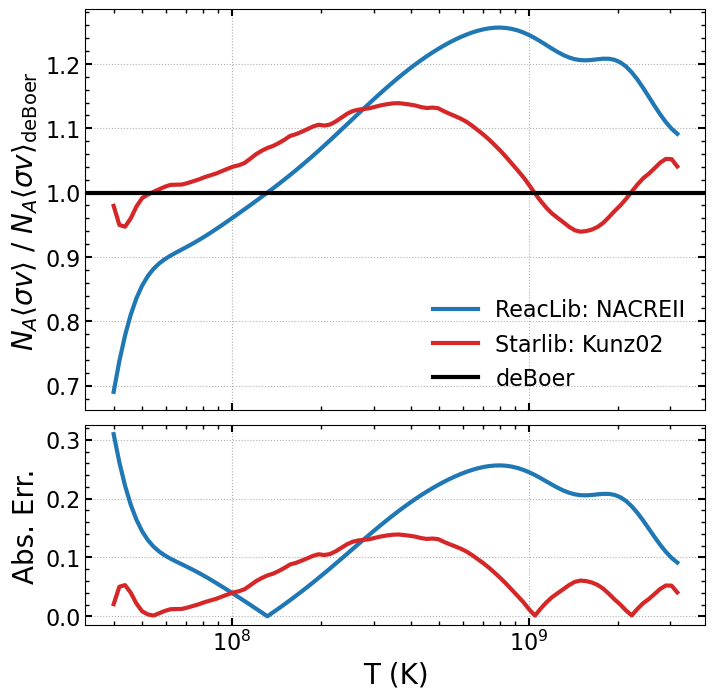

In [7]:
fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

# Top panel
ax.semilogx(Ts, r1_reaclib / r_deboer, label="ReacLib: NACREII", color="tab:blue")
ax.semilogx(Ts, r1_starlib / r_deboer, label="Starlib: Kunz02", color="tab:red")
ax.axhline(1.0, color="k", label="deBoer")

ax.set_ylabel(r"$N_A\langle \sigma v\rangle$ / $N_A\langle \sigma v\rangle_{\mathrm{deBoer}}$ ")
ax.grid(ls=":")
ax.legend(frameon=False)

# Bot panel
rel_reaclib = np.abs(r1_reaclib - r_deboer) / r_deboer
rel_starlib = np.abs(r1_starlib - r_deboer) / r_deboer

ax_err.semilogx(Ts, rel_reaclib, label="ReacLib", color="tab:blue")
ax_err.semilogx(Ts, rel_starlib, label="StarLib", color="tab:red")

ax_err.set_xlabel("T (K)")
ax_err.set_ylabel("Abs. Err.")
ax_err.grid(ls=":")

for a in (ax, ax_err):
    a.minorticks_on()
    a.tick_params(top=True, bottom=True,
                  left=True, right=True,
                  direction="in", which="both")

fig.tight_layout()
fig.savefig("alternate-rates-deboer.pdf", bbox_inches="tight")

## Iliadis O16(p,g)F17

Now we do the same comparison with ${}^{16}\mathrm{O}(p,\gamma){}^{17}\mathrm{F}$ 
rate from [iliadis et al. 2022](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.106.055802).

In [8]:
O16pgF17_iliadis = pyna.rates.alternate_rates.IliadisO16pgF17()
O16pgF17_iliadis.source

{'Label': 'iliadis2022',
 'Author': 'C. Iliadis, V. Palanivelrajan, R. S. de Souza',
 'Title': 'Bayesian estimation of the ?factor and thermonuclear reaction rate for 16O(?,?)17F',
 'Publisher': 'Phys Rev C 106, 055802',
 'Year': '2022',
 'URL': 'https://doi.org/10.1103/PhysRevC.106.055802'}

In [9]:
O16pgF17_reaclib = reaclib_library.get_rate_by_name("o16(p,g)f17")
O16pgF17_reaclib.source

{'Label': 'ia08',
 'Author': 'Iliadis, C.',
 'Title': 'New reaction rate for 16O( p,&gamma;)17F and its influence on the oxygen isotopic ratios in massive AGB stars',
 'Publisher': 'PRC77, 045802',
 'Year': '2008',
 'URL': 'https://doi.org/10.1103/PhysRevC.77.045802'}

In [10]:
O16pgF17_starlib = starlib_library.get_rate_by_name("o16(p,g)f17")
O16pgF17_starlib.source

{'Label': 'mc10',
 'Author': 'C. Iliadis et al.',
 'Title': 'Charged-particle thermonuclear reaction rates: II. Tables and graphs of reaction rates and probability density functions',
 'Publisher': 'NPA 841, 31',
 'Year': '2010',
 'URL': 'https://doi.org/10.1016/j.nuclphysa.2010.04.009'}

In [11]:
Ts = np.logspace(np.log10(np.exp(O16pgF17_starlib.log_t9_data)[0]*1e9), 9.5, 100)

r_iliadis = np.array([O16pgF17_iliadis.eval(T) for T in Ts])
r2_reaclib = np.array([O16pgF17_reaclib.eval(T) for T in Ts])
r2_starlib = np.array([O16pgF17_starlib.eval(T) for T in Ts])

/tmp/ipykernel_120634/1433527880.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


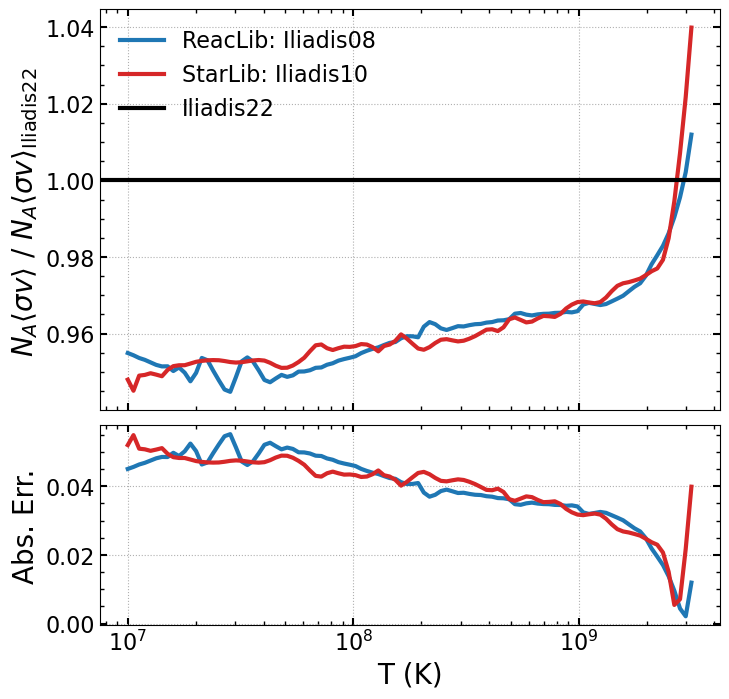

In [12]:
fig, (ax, ax_err) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1], "hspace": 0.05})

# Top panel
ax.semilogx(Ts, r2_reaclib / r_iliadis, label="ReacLib: Iliadis08", color="tab:blue")
ax.semilogx(Ts, r2_starlib / r_iliadis, label="StarLib: Iliadis10", color="tab:red")
ax.axhline(1.0, color="k", label="Iliadis22")

ax.set_ylabel(r"$N_A\langle \sigma v\rangle$ / $N_A\langle \sigma v\rangle_{\mathrm{Iliadis22}}$ ")
ax.grid(ls=":")
ax.legend(frameon=False)

# Bot panel
rel_reaclib = np.abs(r2_reaclib - r_iliadis) / r_iliadis
rel_starlib = np.abs(r2_starlib - r_iliadis) / r_iliadis

ax_err.semilogx(Ts, rel_reaclib, label="ReacLib", color="tab:blue")
ax_err.semilogx(Ts, rel_starlib, label="StarLib", color="tab:red")

ax_err.set_xlabel("T (K)")
ax_err.set_ylabel("Abs. Err.")
ax_err.grid(ls=":")

for a in (ax, ax_err):
    a.minorticks_on()
    a.tick_params(top=True, bottom=True,
                  left=True, right=True,
                  direction="in", which="both")

fig.tight_layout()
fig.savefig("alternate-rates-iliadis.pdf", bbox_inches="tight")